# Simulations and testing

These simulations are based on the `simulation_master.py` module. All simulations are versions of AR(1) models.

First we import relevant libraries and the module file.

In [1]:
# to run R code
%load_ext rpy2.ipython

# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import os
import sys
import importlib

# add path to the module
sys.path.append(os.path.abspath(".."))

# import functions
from simulation import simulation_master

# reload functions
importlib.reload(simulation_master)

Error importing in API mode: ImportError("dlopen(/opt/anaconda3/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so, 0x0002): Library not loaded: /Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib\n  Referenced from: <BBF229FE-E7FC-30D6-AD24-713D50386A7C> /opt/anaconda3/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so\n  Reason: tried: '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file)")
Trying to import in ABI mode.


<module 'simulation.simulation_master' from '/Users/emilrand/Desktop/ku/Bachelor/6. semester/ba/ba_repo/simulation/simulation_master.py'>

### Random walk with drift - no bubble

First we simulate, plot and save $P_t$ as .csv file.

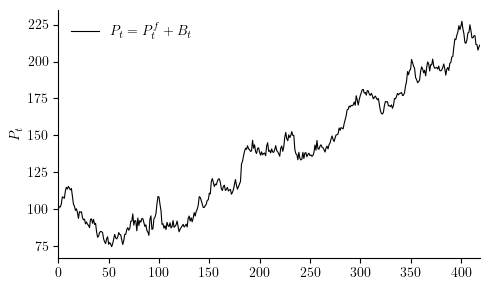

In [3]:
# simulate random walk with drift - no bubble

Pf_nobubble, B_nobubble, P_nobubble = simulation_master.simulate_price_with_bubbles(
    
    # Sample size
    T = 420,
    
    # Fundamental component
    rho_f = 1.0,
    mu_f = 0.2,
    sigma_f = 3,
    Pf0 = 100.0,

    # Random seed
    seed = 42,
    
)

# font
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'

# plot
plt.figure(figsize=(5, 3))
plt.plot(P_nobubble.index, P_nobubble.values, color='black', linewidth=0.8, ls='-', label=r'$P_t = P_t^f + B_t$')
plt.ylabel(r'$P_t$')

# formatting
plt.tight_layout()
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:,.0f}".replace(",", ".")))
# plt.grid(True, alpha=0.5, linestyle='--')
plt.legend(frameon=False, loc='upper left')
plt.xlim(P_nobubble.index.min(), P_nobubble.index.max())

# cleaner axes
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# save and show
plt.savefig('plots/P_nobubble.pdf')
P_nobubble = P_nobubble.rename('P_nobubble')
P_nobubble.to_csv('data/P_nobubble.csv', index=False)
plt.show()

Next we use the exuber package from R, to apply BSADF and GSADF methods to the series, and download the series. 

In [4]:
%%R
library(exuber)

# 1. Load series
dat <- read.csv('data/P_nobubble.csv') #../../data/simulated/timeseries/P_late_bubble.csv
y   <- ts(dat$P_nobubble)     # change after $ to the column name
T   <- length(y)

# 2. Test statistics (ADF, SADF, GSADF)
res  <- radf(y, lag = 0)

# 3. Critical values (Monte Carlo)
cv   <- radf_mc_cv(n = T, nrep = 2000, seed = 123)

options(digits = 10)
print(res)
print(cv)

# BSADF critical values (90%, 95%, 99%) and test statistic
cv$bsadf_cv # cv
res$bsadf   # test statistic

# download BSADF data

# BSADF test statistic over time
bsadf_stat <- data.frame(bsadf = as.numeric(res$bsadf))
write.csv(bsadf_stat, "results/P_nobubble_bsadf.csv", row.names = FALSE)

# BSADF critical values (90, 95, 99)
bsadf_cv <- as.data.frame(cv$bsadf_cv)        # keep all significance-level columns
write.csv(bsadf_cv, "results/P_nobubble_cv.csv", row.names = FALSE)


── radf (minw = 41, lag = 0) ───────────────────────────────────────────────────

       id           adf       sadf     gsadf
  series1  -0.002566557  0.7670181  1.578873

  gsadf_panel
     1.578873


── Monte Carlo (minw = 41, nrep = 2000) ────────────────────────────────────────

  sig          adf      sadf     gsadf
   90  -0.42229340  1.146362  1.934428
   95  -0.05957989  1.448922  2.162211
   99   0.55426333  2.039598  2.622547



Finally we plot the BSADF stats with 95 and 99% critical values. 

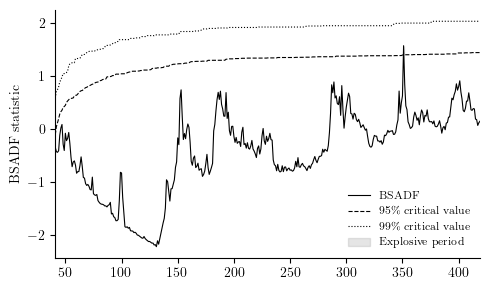

In [5]:
# font
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'

# data
bsadf_stat = pd.read_csv("results/P_nobubble_bsadf.csv")
bsadf_cv   = pd.read_csv("results/P_nobubble_cv.csv")
t = P_nobubble.index[-len(bsadf_stat):]

# plot
plt.figure(figsize=(5, 3))
plt.plot(t, bsadf_stat["bsadf"], color='black', linewidth=0.8, ls='-', label='BSADF')
plt.plot(t, bsadf_cv["95%"], color='black', linewidth=0.8, ls='--', label=r'95\% critical value')
plt.plot(t, bsadf_cv["99%"], color='black', linewidth=0.8, ls=':', label=r'99\% critical value')

plt.fill_between(t, # optional shading of explosive periods for 95% cv
                 bsadf_stat["bsadf"],
                 bsadf_cv["95%"],
                 where=(bsadf_stat["bsadf"] > bsadf_cv["95%"]),
                 color='grey',
                 alpha=0.2,
                 label='Explosive period')

# labels
plt.ylabel('BSADF statistic')

# formatting
plt.tight_layout()
# plt.grid(True, alpha=0.5, linestyle='--')
plt.legend(frameon=False, loc='lower right', fontsize=8)

plt.xlim(t.min(), t.max())

# cleaner axes
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# save
plt.savefig("plots/P_nobubble_bsadf.pdf", bbox_inches="tight")
plt.show()

### Random walk with with drift - 3 bubbles (simulating dot-com, corona, and AI)

If we define bubble periods as:

- dot-com bubble: january 1995 -> october 2002
- covid bubble: april 2020 -> july 2021
- ai bubble: january 2023 -> december 2025

And the sample length as januar 1990 -> december 2025, then there are with monthly data: $(2025 - 1990 + 1)\cdot 12 = 432$ observations. Using the periods as above we get:

- dot-com bubble: 61 -> 154
- covid bubble: 364 -> 382
- ai bubble: 397 -> 432

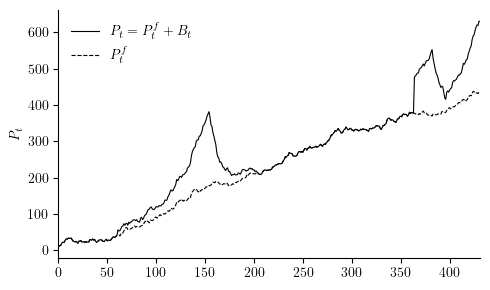

In [43]:
# simulate random walk with drift - 3 bubbles

Pf_3bubbles, B_3bubbles, P_3bubbles = simulation_master.simulate_price_with_bubbles(
    
    # Sample size
    T = 432,
    
    # Fundamental component
    rho_f = 1.0,
    mu_f = 1.0,
    sigma_f = 3.0,
    Pf0 = 10.0,

    # Bubble component
    include_bubble = True,
    R = 0.04,
    sigma_b = 4.0,
    omega = 0.9,
    B0 = 0.0,

    # a. First bubble interval (dot-com)
    tau_s1 = 61,
    tau_e1 = 154,
    B0_1 = 15.0,

    # b. Second bubble interval (COVID)
    tau_s2 = 364,
    tau_e2 = 382,
    B0_2 = 100.0,

    # c. Third bubble interval (AI)
    tau_s3 = 397,
    tau_e3 = 432,
    B0_3 = 50.0,

    # Random seed
    seed = 42,

)

# font
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'

# plot
plt.figure(figsize=(5, 3))
plt.plot(P_3bubbles.index, P_3bubbles.values, color='black', linewidth=0.8, ls='-', label=r'$P_t = P_t^f + B_t$')
plt.plot(Pf_3bubbles.index, Pf_3bubbles.values, color='black', linewidth=0.8, ls='--', label=r'$P_t^f$')
plt.ylabel(r'$P_t$')

# formatting
plt.tight_layout()
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:,.0f}".replace(",", ".")))
# plt.grid(True, alpha=0.5, linestyle='--')
plt.legend(frameon=False, loc='upper left')
plt.xlim(P_3bubbles.index.min(), P_3bubbles.index.max())

# cleaner axes
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# save and show
plt.savefig('plots/P_3bubbles.pdf')
P_3bubbles = P_3bubbles.rename('P_3bubbles')
P_3bubbles.to_csv('data/P_3bubbles.csv', index=False)
plt.show()

Next up, testing:

In [44]:
%%R
library(exuber)

# 1. Load series
dat <- read.csv('data/P_3bubbles.csv') #../../data/simulated/timeseries/P_late_bubble.csv
y   <- ts(dat$P_3bubbles)     # change after $ to the column name
T   <- length(y)

# 2. Test statistics (ADF, SADF, GSADF)
res  <- radf(y, lag = 0)

# 3. Critical values (Monte Carlo)
cv   <- radf_mc_cv(n = T, nrep = 2000, seed = 123)

options(digits = 10)
print(res)
print(cv)

# BSADF critical values (90%, 95%, 99%) and test statistic
cv$bsadf_cv # cv
res$bsadf   # test statistic

# download BSADF data

# BSADF test statistic over time
bsadf_stat <- data.frame(bsadf = as.numeric(res$bsadf))
write.csv(bsadf_stat, "results/P_3bubbles_bsadf.csv", row.names = FALSE)

# BSADF critical values (90, 95, 99)
bsadf_cv <- as.data.frame(cv$bsadf_cv)        # keep all significance-level columns
write.csv(bsadf_cv, "results/P_3bubbles_cv.csv", row.names = FALSE)


── radf (minw = 41, lag = 0) ───────────────────────────────────────────────────

       id       adf      sadf     gsadf
  series1  1.187061  6.366268  6.494763

  gsadf_panel
     6.494763


── Monte Carlo (minw = 41, nrep = 2000) ────────────────────────────────────────

  sig          adf      sadf     gsadf
   90  -0.39620743  1.151958  1.940131
   95  -0.03740744  1.450801  2.165954
   99   0.63280779  2.039598  2.622547



Now plotting BSADF

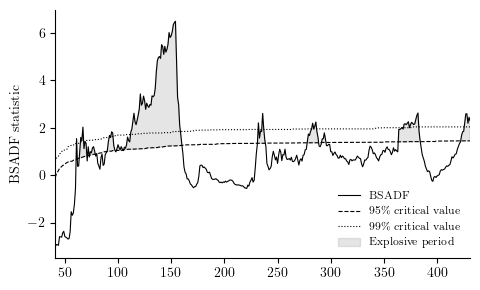

In [45]:
# font
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'

# data
bsadf_stat = pd.read_csv("results/P_3bubbles_bsadf.csv")
bsadf_cv   = pd.read_csv("results/P_3bubbles_cv.csv")
t = P_3bubbles.index[-len(bsadf_stat):]

# plot
plt.figure(figsize=(5, 3))
plt.plot(t, bsadf_stat["bsadf"], color='black', linewidth=0.8, ls='-', label='BSADF')
plt.plot(t, bsadf_cv["95%"], color='black', linewidth=0.8, ls='--', label=r'95\% critical value')
plt.plot(t, bsadf_cv["99%"], color='black', linewidth=0.8, ls=':', label=r'99\% critical value')

plt.fill_between(t, # optional shading of explosive periods for 95% cv
                 bsadf_stat["bsadf"],
                 bsadf_cv["95%"],
                 where=(bsadf_stat["bsadf"] > bsadf_cv["95%"]),
                 color='grey',
                 alpha=0.2,
                 label='Explosive period')

# labels
plt.ylabel('BSADF statistic')

# formatting
plt.tight_layout()
# plt.grid(True, alpha=0.5, linestyle='--')
plt.legend(frameon=False, loc='lower right', fontsize=8)

plt.xlim(t.min(), t.max())

# cleaner axes
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# save
plt.savefig("plots/P_3bubbles_bsadf.pdf", bbox_inches="tight")
plt.show()

In [46]:
%%R
library(exuber)

## now only with 2015 - 2025 (301-432)

# 1. Load series and keep observations 301:432
dat <- read.csv('data/P_3bubbles.csv')
y   <- ts(dat$P_3bubbles[301:432])
T   <- length(y)

# 2. Test statistics (ADF, SADF, GSADF)
res <- radf(y, lag = 0)

# 3. Critical values (Monte Carlo)
cv  <- radf_mc_cv(n = T, nrep = 2000, seed = 123)

options(digits = 10)
print(res)
print(cv)

# BSADF and GSADF outputs
cv$bsadf_cv
res$bsadf
res$gsadf

# Save BSADF test statistic over time
bsadf_stat <- data.frame(bsadf = as.numeric(res$bsadf))
write.csv(bsadf_stat, "results/P_3bubbles_301_432_bsadf.csv", row.names = FALSE)

# Save BSADF critical values (90, 95, 99)
bsadf_cv <- as.data.frame(cv$bsadf_cv)
write.csv(bsadf_cv, "results/P_3bubbles_301_432_cv.csv", row.names = FALSE)


── radf (minw = 22, lag = 0) ───────────────────────────────────────────────────

       id        adf      sadf     gsadf
  series1  0.7503298  1.614103  2.641659

  gsadf_panel
     2.641659


── Monte Carlo (minw = 22, nrep = 2000) ────────────────────────────────────────

  sig         adf      sadf     gsadf
   90  -0.4496014  1.002152  1.771418
   95  -0.1377478  1.330626  2.052327
   99   0.6666404  1.930828  2.631734



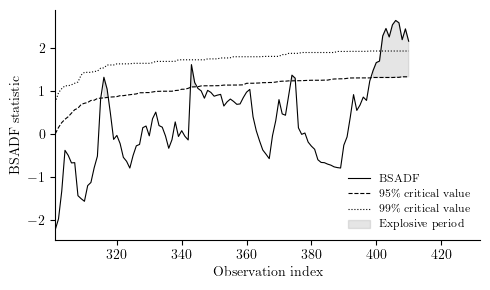

In [47]:
# font
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'

# data
bsadf_stat = pd.read_csv("results/P_3bubbles_301_432_bsadf.csv")
bsadf_cv   = pd.read_csv("results/P_3bubbles_301_432_cv.csv")
t = np.arange(301, 301 + len(bsadf_stat))

# plot
plt.figure(figsize=(5, 3))
plt.plot(t, bsadf_stat["bsadf"], color='black', linewidth=0.8, ls='-', label='BSADF')
plt.plot(t, bsadf_cv["95%"], color='black', linewidth=0.8, ls='--', label=r'95\% critical value')
plt.plot(t, bsadf_cv["99%"], color='black', linewidth=0.8, ls=':', label=r'99\% critical value')

plt.fill_between(t, # optional shading of explosive periods for 95% cv
                 bsadf_stat["bsadf"],
                 bsadf_cv["95%"],
                 where=(bsadf_stat["bsadf"] > bsadf_cv["95%"]),
                 color='grey',
                 alpha=0.2,
                 label='Explosive period')

# labels
plt.ylabel('BSADF statistic')
plt.xlabel('Observation index')

# formatting
plt.tight_layout()
# plt.grid(True, alpha=0.5, linestyle='--')
plt.legend(frameon=False, loc='lower right', fontsize=8)

plt.xlim(301, 432)

# cleaner axes
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# save
plt.savefig("plots/P_3bubbles_301_432_bsadf.pdf", bbox_inches="tight")
plt.show()

### Late bubble example

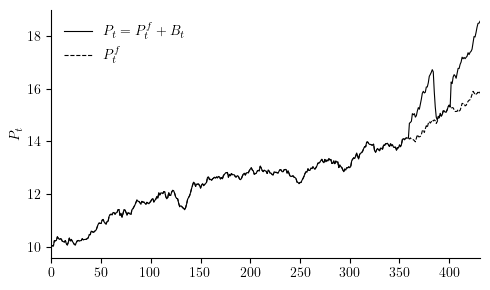

In [52]:
# late bubble

Pf_latebubbles, B_latebubbles, P_latebubbles = simulation_master.simulate_price_with_bubbles(
    
    # Sample size
    T = 432,
    
    # Fundamental component
    rho_f = 1.0,
    mu_f = 0.01,
    sigma_f = 0.08,
    Pf0 = 10.0,

    # Bubble component
    include_bubble = True,
    R = 0.04,
    sigma_b = 0.1,
    omega = 0.6,
    B0 = 0.0,

    # covid
    tau_s1 = 360,
    tau_e1 = 384,
    B0_1 = 0.6,
    # ai
    tau_s2 = 402,
    tau_e2 = 432,
    B0_2 = 1.0,

    # seed
    seed = 5,

)

# font
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'

# plot
plt.figure(figsize=(5, 3))
plt.plot(P_latebubbles.index, P_latebubbles.values, color='black', linewidth=0.8, ls='-', label=r'$P_t = P_t^f + B_t$')
plt.plot(Pf_latebubbles.index, Pf_latebubbles.values, color='black', linewidth=0.8, ls='--', label=r'$P_t^f$')
plt.ylabel(r'$P_t$')

# formatting
plt.tight_layout()
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:,.0f}".replace(",", ".")))
# plt.grid(True, alpha=0.5, linestyle='--')
plt.legend(frameon=False, loc='upper left')
plt.xlim(P_latebubbles.index.min(), P_latebubbles.index.max())

# cleaner axes
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# save and show
plt.savefig('plots/P_latebubbles.pdf')
P_latebubbles = P_latebubbles.rename('P_latebubbles')
P_latebubbles.to_csv('data/P_latebubbles.csv', index=False)
plt.show()

In [53]:
%%R
library(exuber)

# 1. Load series
dat <- read.csv('data/P_latebubbles.csv') #../../data/simulated/timeseries/P_late_bubble.csv
y   <- ts(dat$P_latebubbles)     # change after $ to the column name
T   <- length(y)

# 2. Test statistics (ADF, SADF, GSADF)
res  <- radf(y, lag = 0)

# 3. Critical values (Monte Carlo)
cv   <- radf_mc_cv(n = T, nrep = 2000, seed = 123)

options(digits = 10)
print(res)
print(cv)

# BSADF critical values (90%, 95%, 99%) and test statistic
cv$bsadf_cv # cv
res$bsadf   # test statistic

# download BSADF data

# BSADF test statistic over time
bsadf_stat <- data.frame(bsadf = as.numeric(res$bsadf))
write.csv(bsadf_stat, "results/P_latebubbles_bsadf.csv", row.names = FALSE)

# BSADF critical values (90, 95, 99)
bsadf_cv <- as.data.frame(cv$bsadf_cv)        # keep all significance-level columns
write.csv(bsadf_cv, "results/P_latebubbles_cv.csv", row.names = FALSE)


── radf (minw = 41, lag = 0) ───────────────────────────────────────────────────

       id       adf      sadf     gsadf
  series1  2.077045  2.077045  3.874738

  gsadf_panel
     3.874738


── Monte Carlo (minw = 41, nrep = 2000) ────────────────────────────────────────

  sig          adf      sadf     gsadf
   90  -0.39620743  1.151958  1.940131
   95  -0.03740744  1.450801  2.165954
   99   0.63280779  2.039598  2.622547



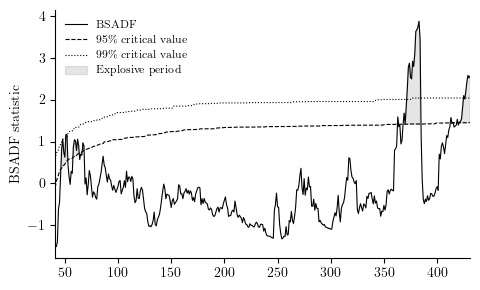

In [55]:
# font
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'

# data
bsadf_stat = pd.read_csv("results/P_latebubbles_bsadf.csv")
bsadf_cv   = pd.read_csv("results/P_latebubbles_cv.csv")
t = P_3bubbles.index[-len(bsadf_stat):]

# plot
plt.figure(figsize=(5, 3))
plt.plot(t, bsadf_stat["bsadf"], color='black', linewidth=0.8, ls='-', label='BSADF')
plt.plot(t, bsadf_cv["95%"], color='black', linewidth=0.8, ls='--', label=r'95\% critical value')
plt.plot(t, bsadf_cv["99%"], color='black', linewidth=0.8, ls=':', label=r'99\% critical value')

plt.fill_between(t, # optional shading of explosive periods for 95% cv
                 bsadf_stat["bsadf"],
                 bsadf_cv["95%"],
                 where=(bsadf_stat["bsadf"] > bsadf_cv["95%"]),
                 color='grey',
                 alpha=0.2,
                 label='Explosive period')

# labels
plt.ylabel('BSADF statistic')

# formatting
plt.tight_layout()
# plt.grid(True, alpha=0.5, linestyle='--')
plt.legend(frameon=False, loc='upper left', fontsize=8)

plt.xlim(t.min(), t.max())

# cleaner axes
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# save
plt.savefig("plots/P_latebubbles_bsadf.pdf", bbox_inches="tight")
plt.show()

In [56]:
%%R
library(exuber)

## now only with 2015 - 2025 (301-432)

# 1. Load series and keep observations 301:432
dat <- read.csv('data/P_latebubbles.csv')
y   <- ts(dat$P_latebubbles[301:432])
T   <- length(y)

# 2. Test statistics (ADF, SADF, GSADF)
res <- radf(y, lag = 0)

# 3. Critical values (Monte Carlo)
cv  <- radf_mc_cv(n = T, nrep = 2000, seed = 123)

options(digits = 10)
print(res)
print(cv)

# BSADF and GSADF outputs
cv$bsadf_cv
res$bsadf
res$gsadf

# Save BSADF test statistic over time
bsadf_stat <- data.frame(bsadf = as.numeric(res$bsadf))
write.csv(bsadf_stat, "results/P_latebubbles_301_432_bsadf.csv", row.names = FALSE)

# Save BSADF critical values (90, 95, 99)
bsadf_cv <- as.data.frame(cv$bsadf_cv)
write.csv(bsadf_cv, "results/P_latebubbles_301_432_cv.csv", row.names = FALSE)


── radf (minw = 22, lag = 0) ───────────────────────────────────────────────────

       id        adf      sadf     gsadf
  series1  0.7790514  1.925852  2.444696

  gsadf_panel
     2.444696


── Monte Carlo (minw = 22, nrep = 2000) ────────────────────────────────────────

  sig         adf      sadf     gsadf
   90  -0.4496014  1.002152  1.771418
   95  -0.1377478  1.330626  2.052327
   99   0.6666404  1.930828  2.631734



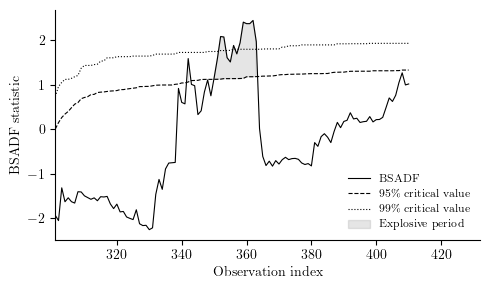

In [57]:
# font
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'

# data
bsadf_stat = pd.read_csv("results/P_latebubbles_301_432_bsadf.csv")
bsadf_cv   = pd.read_csv("results/P_latebubbles_301_432_cv.csv")
t = np.arange(301, 301 + len(bsadf_stat))

# plot
plt.figure(figsize=(5, 3))
plt.plot(t, bsadf_stat["bsadf"], color='black', linewidth=0.8, ls='-', label='BSADF')
plt.plot(t, bsadf_cv["95%"], color='black', linewidth=0.8, ls='--', label=r'95\% critical value')
plt.plot(t, bsadf_cv["99%"], color='black', linewidth=0.8, ls=':', label=r'99\% critical value')

plt.fill_between(t, # optional shading of explosive periods for 95% cv
                 bsadf_stat["bsadf"],
                 bsadf_cv["95%"],
                 where=(bsadf_stat["bsadf"] > bsadf_cv["95%"]),
                 color='grey',
                 alpha=0.2,
                 label='Explosive period')

# labels
plt.ylabel('BSADF statistic')
plt.xlabel('Observation index')

# formatting
plt.tight_layout()
# plt.grid(True, alpha=0.5, linestyle='--')
plt.legend(frameon=False, loc='lower right', fontsize=8)

plt.xlim(301, 432)

# cleaner axes
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# save
plt.savefig("plots/P_latebubbles_301_432_bsadf.pdf", bbox_inches="tight")
plt.show()

## Monte carlo simulation example

### Simulate the late bubble time series 200 times

In a loop we generate the same simulated price 200 times, and save each time series in a new column in a .csv file.

In [69]:
N = 200
all_series = pd.DataFrame()
seed = 42
np.random.seed(seed)

for i in range(N):
    Pf, B, P = simulation_master.simulate_price_with_bubbles(
        T=432,
        rho_f=1.0,
        mu_f=0.01,
        sigma_f=0.08,
        Pf0=10.0,
        include_bubble=True,
        R=0.04,
        sigma_b=0.1,
        omega=0.6,
        B0=0.0,
        tau_s1=360,
        tau_e1=384,
        B0_1=0.6,
        tau_s2=402,
        tau_e2=432,
        B0_2=1.0,
        seed=None,
    )

    all_series[f"sim_{i+1}"] = P.values

all_series.to_csv("data/P_latebubbles_MC.csv", index=False)

/var/folders/z6/_5mml4hx7yb_335wjw124bph0000gq/T/ipykernel_26794/6509361.py:27: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  all_series[f"sim_{i+1}"] = P.values
/var/folders/z6/_5mml4hx7yb_335wjw124bph0000gq/T/ipykernel_26794/6509361.py:27: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  all_series[f"sim_{i+1}"] = P.values
/var/folders/z6/_5mml4hx7yb_335wjw124bph0000gq/T/ipykernel_26794/6509361.py:27: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has po

Now we calculate critical values once, and compute GSADF for every column in the .csv. Then we can calculate rejection rates. 

In [70]:
%%R
library(exuber)

# Load data
dat_full <- read.csv("data/P_latebubbles_MC.csv")

# Create short sample (301–432)
dat_short <- dat_full[301:432, ]

# Sample sizes
T_full  <- nrow(dat_full)
T_short <- nrow(dat_short)

# --------------------------
# FULL SAMPLE
# --------------------------
res_full <- radf(dat_full, lag = 0)
cv_full  <- radf_mc_cv(n = T_full, nrep = 2000, seed = 123)

cv95_full <- cv_full$gsadf_cv[2]
gsadf_full <- as.numeric(res_full$gsadf)

reject_full <- as.numeric(gsadf_full > cv95_full)
rej_rate_full <- mean(reject_full)

# --------------------------
# SHORT SAMPLE
# --------------------------
res_short <- radf(dat_short, lag = 0)
cv_short  <- radf_mc_cv(n = T_short, nrep = 2000, seed = 123)

cv95_short <- cv_short$gsadf_cv[2]
gsadf_short <- as.numeric(res_short$gsadf)

reject_short <- as.numeric(gsadf_short > cv95_short)
rej_rate_short <- mean(reject_short)

# --------------------------
# OUTPUT
# --------------------------
print("Rejection rate (95%) - FULL sample:")
print(rej_rate_full)

print("Rejection rate (95%) - SHORT sample:")
print(rej_rate_short)

[1] "Rejection rate (95%) - FULL sample:"
[1] 0.82
[1] "Rejection rate (95%) - SHORT sample:"
[1] 0.615


To test this, we now do it for a random walk in the whole series. Here it should only reject in 5% of the cases. 

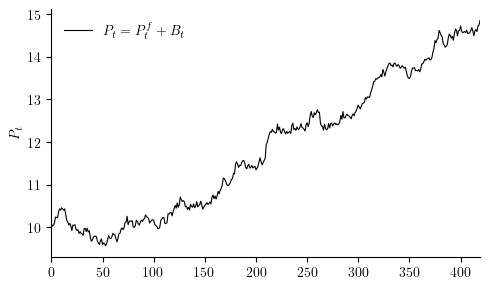

In [66]:
# simulate random walk with drift - no bubble

Pf_nobubble, B_nobubble, P_nobubble = simulation_master.simulate_price_with_bubbles(
    
    # Sample size
    T = 420,
    
    # Fundamental component
    rho_f = 1.0,
    mu_f = 0.01,
    sigma_f = 0.08,
    Pf0 = 10.0,

    include_bubble=False, # no bubble

    # Random seed
    seed = 42,
    
)

# font
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'

# plot
plt.figure(figsize=(5, 3))
plt.plot(P_nobubble.index, P_nobubble.values, color='black', linewidth=0.8, ls='-', label=r'$P_t = P_t^f + B_t$')
plt.ylabel(r'$P_t$')

# formatting
plt.tight_layout()
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:,.0f}".replace(",", ".")))
# plt.grid(True, alpha=0.5, linestyle='--')
plt.legend(frameon=False, loc='upper left')
plt.xlim(P_nobubble.index.min(), P_nobubble.index.max())

# cleaner axes
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# save and show
plt.savefig('plots/P_nobubble.pdf')
P_nobubble = P_nobubble.rename('P_nobubble')
P_nobubble.to_csv('data/P_nobubble.csv', index=False)
plt.show()

In [67]:
N = 200
all_series = pd.DataFrame()
seed = 5
np.random.seed(seed)

for i in range(N):
    Pf, B, P = simulation_master.simulate_price_with_bubbles(

        # Sample size
        T = 420,
    
        # Fundamental component
        rho_f = 1.0,
        mu_f = 0.01,
        sigma_f = 0.08,
        Pf0 = 10.0,

        include_bubble=False, # no bubble
    )

    all_series[f"sim_{i+1}"] = P.values

all_series.to_csv("data/P_nobubble_MC.csv", index=False)

/var/folders/z6/_5mml4hx7yb_335wjw124bph0000gq/T/ipykernel_26794/1072688957.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  all_series[f"sim_{i+1}"] = P.values
/var/folders/z6/_5mml4hx7yb_335wjw124bph0000gq/T/ipykernel_26794/1072688957.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  all_series[f"sim_{i+1}"] = P.values
/var/folders/z6/_5mml4hx7yb_335wjw124bph0000gq/T/ipykernel_26794/1072688957.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, whi

In [68]:
%%R
library(exuber)

# Load all simulated series
dat <- read.csv("data/P_nobubble_MC.csv")

# Sample length
T <- nrow(dat)

# Compute test statistics for all columns at once
res <- radf(dat, lag = 0)

# Critical values only once
cv <- radf_mc_cv(n = T, nrep = 2000, seed = 123)

# Extract 95% GSADF critical value
cv_95 <- cv$gsadf_cv[2]

# Extract GSADF test statistics for all columns
gsadf_vals <- as.numeric(res$gsadf)

# Rejection indicator for each column
reject_95 <- as.numeric(gsadf_vals > cv_95)

# Rejection rate
rejection_rate_95 <- mean(reject_95)

print(gsadf_vals)
print(cv$gsadf_cv)
print("Rejection rate (95%):")
print(rejection_rate_95)

  [1] 1.1699029366 2.1232517142 3.0455579390 1.7542734614 1.2574173444
  [6] 1.2529952557 0.8172988819 1.7716701504 2.7655759552 2.2868525869
 [11] 1.4053606429 1.0978373465 1.6057810122 1.4147761579 1.6720160378
 [16] 2.1298787966 1.3385223947 2.1522273251 2.5668763784 1.7437650449
 [21] 1.6316711832 1.8900081410 1.2788705486 1.9973339241 1.5865592302
 [26] 0.5186118343 2.1579560793 1.4381706910 1.4034199785 1.8057159615
 [31] 2.1894866055 1.9243616656 1.4478225786 2.1015047768 2.2846109296
 [36] 1.6881421240 1.3726392149 1.6915327069 1.0943808444 1.5148408895
 [41] 1.6133209295 1.3371655974 1.6880283885 2.0462401030 2.2387605754
 [46] 1.5289708221 1.2976315213 1.6153578926 1.3089771522 1.6907371135
 [51] 1.8517617508 2.6846415066 0.6531909369 1.9936264672 2.2565881772
 [56] 3.2996399739 1.2352142671 1.3195809170 2.1141136348 1.2984493860
 [61] 1.6680736488 1.7322178824 1.1289002748 2.3524707212 2.2260813706
 [66] 1.6064997745 1.8519162550 1.4104892284 2.2366304417 2.4187683223
 [71] 